In [2]:
from tensorflow import keras

### Interpreting what convnets learn
Techniques for visualizing and interpreting convnet representations:

####(1)Visualizing intermediate activations:
This is useful for understanding how successive convnet layers transform their input, and also for getting  a first idea of the meaning of the individual convnet filters.

This consists of displaying the values returned by various convolution and pooling layers in a model, given a certain input (the output of a layer is often called its activation, the output of the activation function).

We want to visualize feature maps with three dimensions: width, height, and depth (channels).

Lets start by loading the model:

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
model = keras.models.load_model("/content/drive/MyDrive/cats_vs_dogs_small/convnet_from_scratch_with_augmentation.keras")

In [5]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,982,084 (7.56 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 991,043 (3.78 MB)

Next we will get input image - a picture of a cat, not the ones the network is trained on.

In [6]:
import numpy as np

In [7]:
img_path = keras.utils.get_file(
    fname='cat.jpg',
    origin='https://img-datasets.s3.amazonaws.com/cat.jpg')   #Download test image

80329/80329 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
def get_img_array(img_path, target_size):
  img = keras.utils.load_img(
      img_path, target_size=target_size)      #open the image file and resize it.

  array = keras.utils.img_to_array(img)    # turns the image into a float32 Numpy array of shape(180, 180, 3)
  array = np.expand_dims(array, axis=0)   # add a dimension to transform the array into a batch of a single sample...
                                            # ..its shape is now(1, 180, 180, 3)
  return array

img_tensor = get_img_array(img_path, target_size=(180, 180))

Lets display the picture:

In [9]:
import matplotlib.pyplot as plt

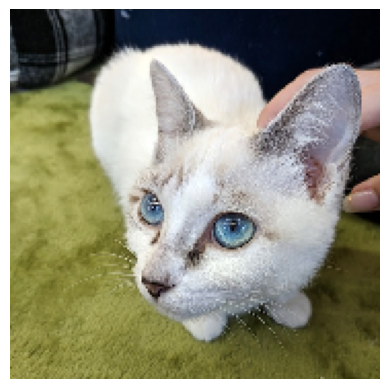

In [10]:
plt.axis('off')
plt.imshow(img_tensor[0].astype('uint8'))
plt.show()

To get the feature maps we want to look at, we will create a keras model that batches of images as input, and that outputs the activation of all convolution and pooling layers

Instantiating the model that returns layer activations:

In [11]:
from tensorflow.keras import layers

In [12]:
layer_outputs = []
layer_names = []

for layer in model.layers:
  if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D)): #extract the ouputs of all Conv2D and MaxPooling2D layers and put them in a list
    layer_outputs.append(layer.output)
    layer_names.append(layer.name)       # save the laye names for later

activation_model = keras.Model(inputs=model.input, outputs=layer_outputs) #create a model that will return these outputs given the model input.

When fed an image input, this model returns the values of the layer activations in the  original model, as a list. This model is a multi-output model, it has  one input and nine outputs: one output per layer activation

####Using the model to compute layer activations

In [13]:
activations = activation_model.predict(img_tensor) #return a list of nine Numpy arrays: one array per layer actication

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


example: An activation of the first convolution layer for the cat image input:

In [14]:
#example
first_layer_activation = activations[0]
print(first_layer_activation.shape)

(1, 178, 178, 32)


In [15]:
len(activations)

9

It’s a 178  178 feature map with 32 channels.
lets try plotting the fifth channel of the activation of the first layer of the original model:

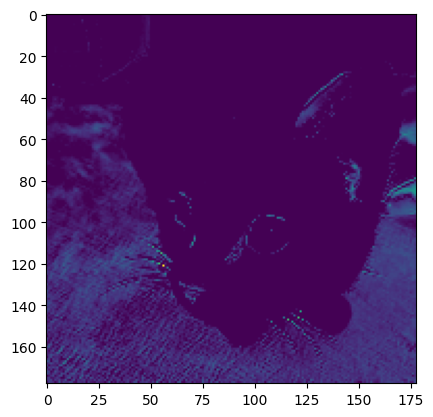

In [16]:
plt.imshow(first_layer_activation[0, :, :, 5], cmap='viridis')

Seems this channel is edge senstive, with brighter activations around the face and ear.